# CS/DS 3262 HW3

### Total: 38/34
### Start date: April 3
### Due date: April 10, 11:59 PM

# Where to submit: GradeScope


# 1. (11 pts) Conceptual questions (All answers can be found from the slides!)

# Double click the cell and enter your answers.

### 1.1 (1 pt) Briefly describe what bias is.

**Bias** is how far the average prediction for each sample is from its true value. Formally: $\mathrm{Bias}^2 = \left(\mathbb{E}[\hat{y}_{\mathrm{test}}] - y_{\mathrm{true}}\right)^2$.

### 1.2 (1 pt) Briefly describe what variance is.

**Variance** is how much the predictions fluctuate across different models for each sample. Formally: $\mathrm{Variance} = \mathbb{E}\left[\left(\hat{y}_{\mathrm{test}} - \mathbb{E}[\hat{y}_{\mathrm{test}}]\right)^2\right]$.

### 1.3 (2 pts) What are overfitting and underfitting? Describe them in terms of model complexity, and explain how the model tends to perform on training and test data in each case.

**Underfitting** happens when a model is too simple (low complexity). It fails to capture the patterns in the data and performs poorly on both training and test data.

**Overfitting** happens when a model is too complex. It fits the training data very well (including its noise), but performs poorly on test data because it does not generalize.

### 1.4 (1 pt) When a model overfits, does it tend to have high or low bias? What about variance?

When a model overfits, it tends to have **low bias**. Its average predictions are close to the true values on the training data. However, it has **high variance** that means its predictions fluctuate a lot across different models or training sets which implies that it does not generalize well.

### 1.5 (1 pt) What are some ways to reduce overfitting? Use a decision tree as one example.

One way to reduce overfitting is to use **ensemble methods** like Random Forest, which is a bagging method that trains multiple decision trees and aggregates their predictions to make a final decision.

For a single **decision tree**, overfitting can be reduced by limiting its complexity. For example, by setting a `max_depth` parameter to prevent the tree from growing too deep and memorizing the training data.

### 1.6 (1 pt) Can you briefly explain what bootstrap sampling is? And how does the resampled data size look like compared with the original one?

**Bootstrap sampling** is a resampling method where data points are randomly selected **with replacement** from the original dataset. Because sampling is done with replacement, the same data point can be picked more than once, and some points may not be selected at all. The resampled dataset is the **same size** as the original dataset. On average, about 63% of the original unique samples appear in each bootstrap sample.

### 1.7 (2 pts) Can you briefly explain what random forest is, and where does the randomness come from (Hint: 2 sources of randomness)?



**Random Forest** is a bagging method that trains multiple decision trees, and the final prediction is made by combining the predictions of all the trees, such as majority voting for classification. The randomness comes from two places:

1. **Random subset of samples:** each tree is trained on a different bootstrap sample of the data, and
2. **Random subset of features:** at each split, the tree considers only a random subset of features instead of all features.

### 1.8 (2 pts) Can you briefly explain what bagging and boosting are? Also, describe their effects on bias and variance.

Bagging means training many models independently on different bootstrap samples and then combining their predictions. Its main effect is to reduce variance.


Boosting means training models one after another, where each new model focuses more on the mistakes made by the earlier ones. Its main effect is to reduce bias, although too much boosting can sometimes increase overfitting.

# 2. (23 pts) Loan Approval Prediction

For this problem, you will build 3 different models (logistic regression, decision tree, random forest) for loan approval prediction and compare their performance.


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# import decision tree from sklearn
from sklearn.tree import DecisionTreeClassifier, plot_tree

# import logistic regression from sklearn
from sklearn.linear_model import LogisticRegression

# import random forest from sklearn
from sklearn.ensemble import RandomForestClassifier

# import data split function
from sklearn.model_selection import train_test_split

#### 2.1 (1 pt) Load data as dataframe and name it `df`:

In [25]:
df = pd.read_csv('loan_approval_dataset.csv')

In [26]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


#### 2.2 Check the data types

`df.dtypes` will return the data type for each column. Run the following code and report what is the data type and report what columns do not have a integer data type.

In [27]:
df.dtypes

,0
loan_id,int64
no_of_dependents,int64
education,object
self_employed,object
income_annum,int64
loan_amount,int64
loan_term,int64
cibil_score,int64
residential_assets_value,int64
commercial_assets_value,int64


#### (1 pt)

Based on `df.dtypes`, the columns that do **not** have an integer (`int64`) data type are:
- **`education`** — `object` (string): contains categorical text values (e.g., `'Graduate'`, `'Not Graduate'`)
- **`self_employed`** — `object` (string): contains categorical text values (e.g., `'Yes'`, `'No'`)
- **`loan_status`** — `object` (string): contains the target label (e.g., `'Approved'`, `'Rejected'`)

All other columns are numeric (`int64`).

#### 2.3 (1 pt) Check and report the unique values for the columns with non-integer data types.

In [28]:

df.columns = df.columns.str.strip()
non_int_cols = ['education', 'self_employed', 'loan_status']

for col in non_int_cols:
    df[col] = df[col].str.strip()

for col in non_int_cols:
    print(f"{col}: {df[col].unique()}")

education: ['Graduate' 'Not Graduate']
self_employed: ['No' 'Yes']
loan_status: ['Approved' 'Rejected']


#### Edit here

The unique values are:
- **`education`**: `['Graduate', 'Not Graduate']`
- **`self_employed`**: `['No', 'Yes']`
- **`loan_status`**: `['Approved', 'Rejected']`

All three columns contain binary categorical string values, which means they can each be encoded with simple label encoding (0 or 1).

#### 2.4 (3 pts) Given your observations, can you encode the categorical features with label encoding? For the last column `loan_status`, map `Rejected` to 0, and `Approved` to 1.

In [29]:

df['education'] = df['education'].map({'Graduate': 1, 'Not Graduate': 0})

df['self_employed'] = df['self_employed'].map({'Yes': 1, 'No': 0})

df['loan_status'] = df['loan_status'].map({'Approved': 1, 'Rejected': 0})

print(df.dtypes)
print(df.head())

loan_id                     int64
no_of_dependents            int64
education                   int64
self_employed               int64
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                 int64
dtype: object
   loan_id  no_of_dependents  education  self_employed  income_annum  \
0        1                 2          1              0       9600000   
1        2                 0          0              1       4100000   
2        3                 3          1              0       9100000   
3        4                 3          1              0       8200000   
4        5                 5          0              1       9800000   

   loan_amount  loan_term  cibil_score  residential_assets_value  \
0     29900000         12          778     

#### 2.5 (1 pt) Split the data into training and test, and set the random state as 42.

In [30]:
# drop target and ID if present
X = df.drop(columns=['loan_status', 'loan_id'], errors='ignore')
y = df['loan_status']

# Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply z-score normalization
train_mean = X_train.mean()
train_std = X_train.std()

train_std = train_std.replace(0, 1)

X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")


Training set size: (3415, 11)
Test set size: (854, 11)


#### 2.6 (6 pts) Now train three separate models: Logistic Regression, Decision Tree, and Random Forest, based on the training data, and report their accuracy on the test data. Which model achieves the highest accuracy?

In [31]:
# --- Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_acc = lr_model.score(X_test_scaled, y_test)
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")

# --- Decision Tree ---
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_acc = dt_model.score(X_test_scaled, y_test)
print(f"Decision Tree Accuracy:       {dt_acc:.4f}")

# --- Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_acc = rf_model.score(X_test_scaled, y_test)
print(f"Random Forest Accuracy:       {rf_acc:.4f}")


best = max([('Logistic Regression', lr_acc), ('Decision Tree', dt_acc), ('Random Forest', rf_acc)], key=lambda x: x[1])
print(f"\nBest model: {best[0]} with accuracy {best[1]:.4f}")

Logistic Regression Accuracy: 0.9052
Decision Tree Accuracy:       0.9778
Random Forest Accuracy:       0.9801

Best model: Random Forest with accuracy 0.9801


**Which model achieves the highest accuracy?**

Based on my results, Random Forest achieved the highest test accuracy (98.01%), slightly higher than Decision Tree (97.78%), followed by Logistic Regression (90.52%). Random Forest likely performed best because it averages across many decision trees, which reduces variance and improves generalization. In this version, all three models were trained using manually z-score normalized features computed from the training-set mean and standard deviation.


#### 2.7 (2 pts) Obtain the feature weights from the logistic regression model and create a bar plot to visualize them.

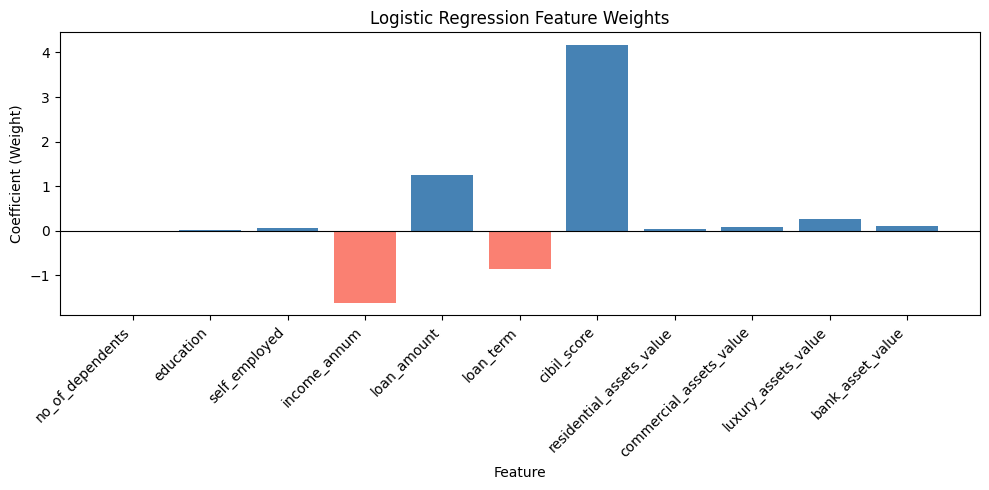

In [32]:
# Get feature names and corresponding logistic regression coefficients
feature_names = X.columns.tolist()
coefficients = lr_model.coef_[0]  # shape: (n_features,)

# Create a bar plot
plt.figure(figsize=(10, 5))
colors = ['steelblue' if c >= 0 else 'salmon' for c in coefficients]
plt.bar(feature_names, coefficients, color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Coefficient (Weight)')
plt.title('Logistic Regression Feature Weights')
plt.tight_layout()
plt.show()

#### 2.8 (2 pts) Based on the plot, identify which features have positive weights and which have negative weights. If an applicant has a lower education level, is the applicant more likely to be rejected or approved for the loan?

#### Edit here

Based on the z-score normalized logistic regression coefficient plot, the features with positive
weights are `education`, `self_employed`, `loan_amount`, `cibil_score`,
`residential_assets_value`, `commercial_assets_value`, `luxury_assets_value`, and
`bank_asset_value`. The features with negative weights are `no_of_dependents`,
`income_annum`, and `loan_term`.


Since `education` was encoded as `Graduate = 1` and `Not Graduate = 0`, the positive
coefficient for `education` means that being a graduate pushes the prediction slightly
more toward approval. Therefore, if an applicant has a lower education level
(`Not Graduate`), the model would consider that applicant somewhat more likely to be
rejected, all else being equal. However, the coefficient for `education` is very small,
so its effect is much weaker than stronger features such as `cibil_score`,
`loan_amount`, `income_annum`, and `loan_term`.

#### 2.9 (2 pts) Use `plot_tree` to visualize the tree structure. Based on the tree, identify a set of features that appear to be the most important.

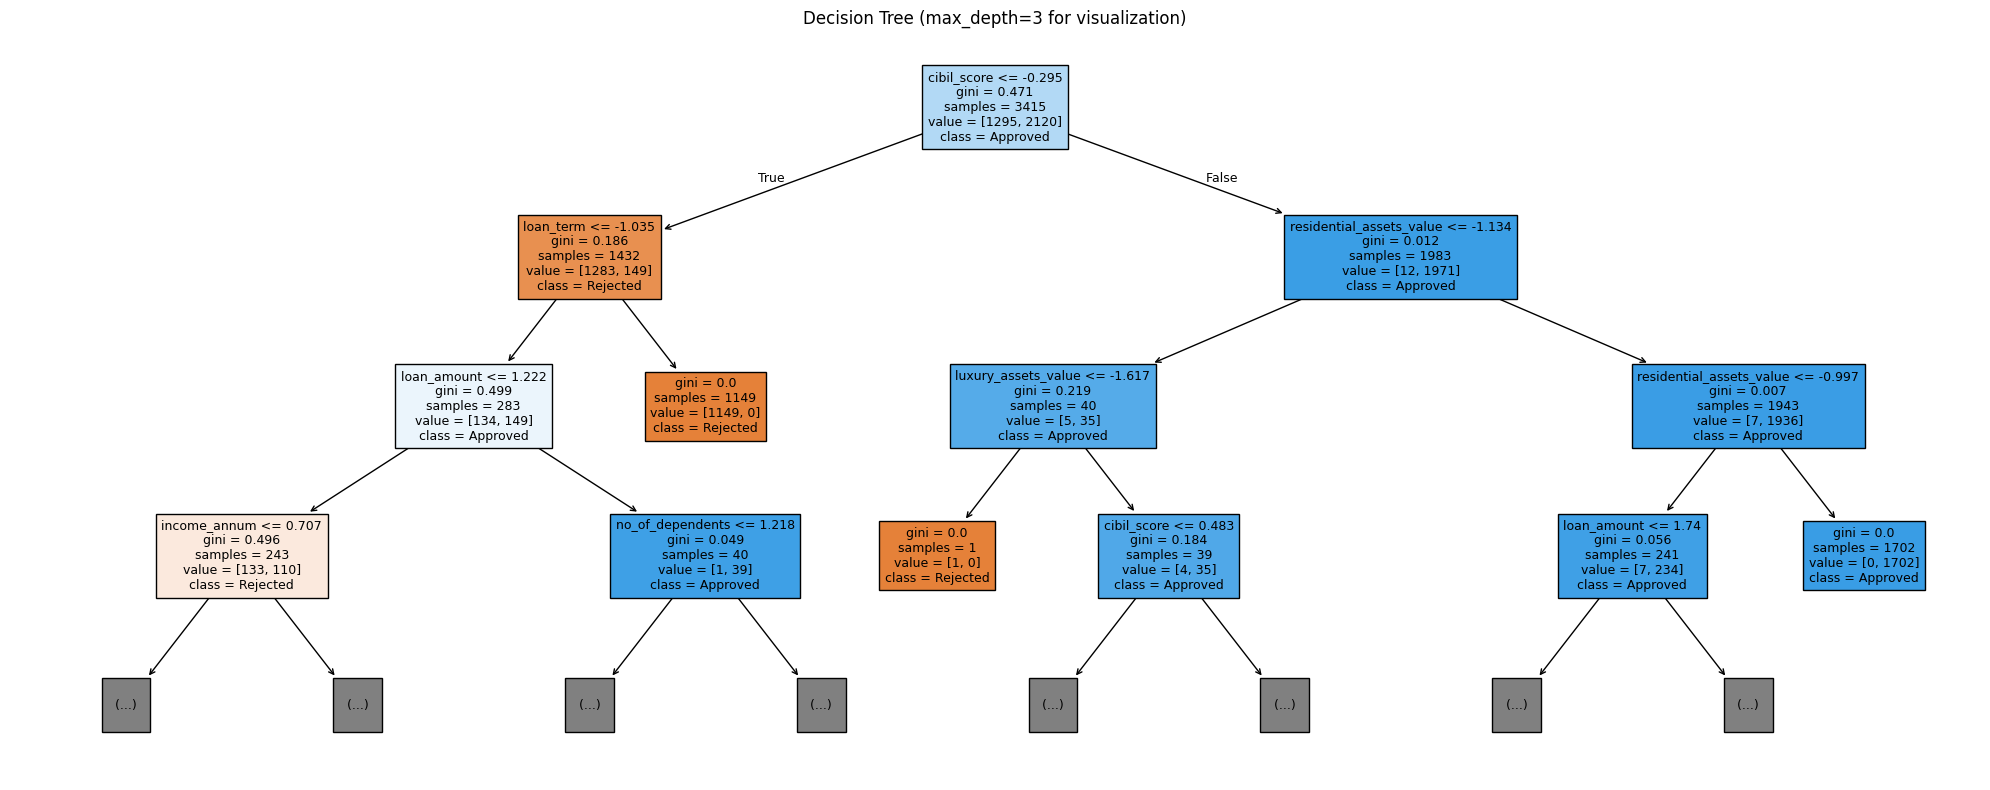

In [33]:
# Visualize the decision tree (limit depth for readability)
plt.figure(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=['Rejected', 'Approved'],
    filled=True,
    max_depth=3,       # for readability
    fontsize=9
)
plt.title('Decision Tree (max_depth=3 for visualization)')
plt.tight_layout()
plt.show()

### What features show more importance (1 pt)?

#### Edit here

The features that appear most important are **`cibil_score`**, **`loan_term`**, and **`residential_assets_value`**, as they appear at the top levels of the tree (root and first splits), meaning they are responsible for the largest reductions in impurity and partition the most samples.

Specifically, `cibil_score` is the root node — the single most important feature — splitting all samples first. `loan_term` and `residential_assets_value` appear at the second level, followed by `loan_amount`, `luxury_assets_value`, and `income_annum` at the third level.

#### 2.10 (2 pts) Obtain the feature importance from the decision tree and create a bar plot for it

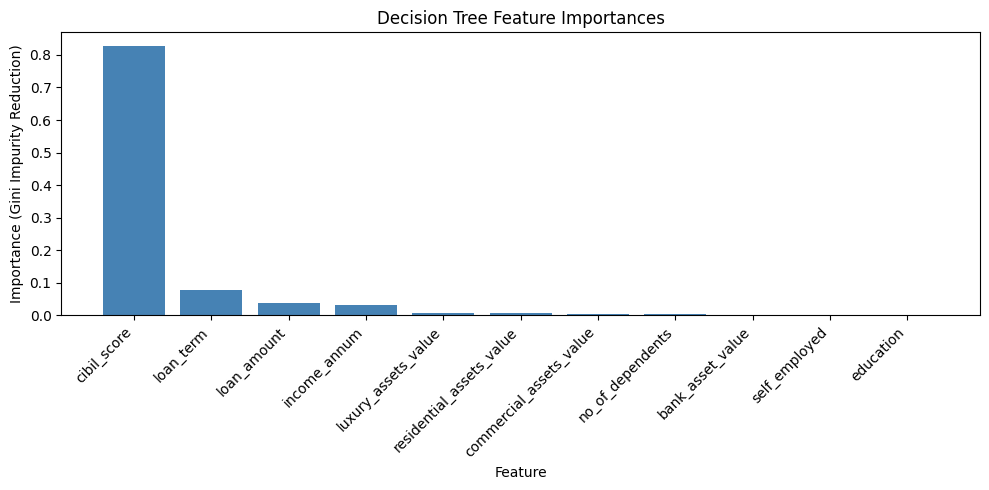

cibil_score: 0.8277
loan_term: 0.0792
loan_amount: 0.0387
income_annum: 0.0313
luxury_assets_value: 0.0072
residential_assets_value: 0.0064
commercial_assets_value: 0.0049
no_of_dependents: 0.0036
bank_asset_value: 0.0009
self_employed: 0.0000
education: 0.0000


In [34]:
# Get feature importances from the trained Decision Tree
dt_importances = dt_model.feature_importances_

# Sort for better visualization
sorted_idx = np.argsort(dt_importances)[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_importances = dt_importances[sorted_idx]

# Bar plot
plt.figure(figsize=(10, 5))
plt.bar(sorted_features, sorted_importances, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Importance (Gini Impurity Reduction)')
plt.title('Decision Tree Feature Importances')
plt.tight_layout()
plt.show()

# Print values
for feat, imp in zip(sorted_features, sorted_importances):
    print(f"{feat}: {imp:.4f}")

#### 2.11 (2 pts) Now compare the feature importance obtained from the Decision Tree model with the feature weights from the Logistic Regression model. If a feature has high importance in the Decision Tree, how does its corresponding weight look in the Logistic Regression model? Does it have a large absolute value compared to other features?

In [35]:
# Create a comparison table: Decision Tree importance vs. Logistic Regression |coefficient|
comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'DT_Importance': dt_model.feature_importances_,
    'LR_Abs_Weight': np.abs(lr_model.coef_[0])
})
comparison_df = comparison_df.sort_values('DT_Importance', ascending=False).reset_index(drop=True)
print(comparison_df.to_string(index=False))

                 Feature  DT_Importance  LR_Abs_Weight
             cibil_score       0.827728       4.163144
               loan_term       0.079202       0.862667
             loan_amount       0.038654       1.260994
            income_annum       0.031342       1.613370
     luxury_assets_value       0.007217       0.271141
residential_assets_value       0.006385       0.034669
 commercial_assets_value       0.004915       0.082806
        no_of_dependents       0.003627       0.028998
        bank_asset_value       0.000931       0.113128
           self_employed       0.000000       0.066444
               education       0.000000       0.022087


**Comparison Analysis:**

#### Edit here

The two models largely agree on the most important features, but not perfectly.

**`cibil_score`** has the highest DT importance (0.8277) by far, and also the largest LR absolute weight (4.163) — strong agreement between both models.

**`loan_term`** and **`loan_amount`** rank 2nd and 3rd in DT importance, and also have relatively large LR absolute weights (0.863 and 1.261 respectively), so both models agree these are meaningful features.

**`income_annum`** is an interesting case — it ranks 4th in DT importance (0.031) but has the 2nd largest LR absolute weight (1.613), suggesting LR finds it more influential than the Decision Tree does.

Features like **`self_employed`** and **`education`** have zero DT importance and near-zero LR weights, so both models consistently agree they contribute very little.

Overall, features with high DT importance tend to have large absolute LR weights, especially for `cibil_score`. However, the relationship is not perfectly consistent — `income_annum` and `loan_amount` show notable differences between the two models, likely because LR captures linear relationships while the Decision Tree captures non-linear splits.

# Bonus 1 (2 pts)
Perform hyperparameter tuning for 2 hyperparameters in Random Forest. What hyperparameter values lead to the highest accuracy?

In [36]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid for 2 hyperparameters:
# n_estimators: number of trees
# max_depth: maximum depth of each tree
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20]
}

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

# Best parameters and accuracy
best_params = grid_search.best_params_
best_rf = grid_search.best_estimator_
best_test_acc = best_rf.score(X_test_scaled, y_test)

print(f"Best hyperparameters: {best_params}")
print(f"Best cross-val accuracy: {grid_search.best_score_:.4f}")
print(f"Test accuracy with best params: {best_test_acc:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best hyperparameters: {'max_depth': None, 'n_estimators': 100}
Best cross-val accuracy: 0.9798
Test accuracy with best params: 0.9801


The two hyperparameters tuned were **`n_estimators`** (number of trees: 50, 100, 200)
and **`max_depth`** (maximum depth per tree: None, 5, 10, 20), tested across 12
combinations using 5-fold cross-validation (60 fits total).

The best hyperparameters found were **`max_depth=None`** and **`n_estimators=100`**,
achieving a cross-validation accuracy of **0.9798** and a test accuracy of **0.9801**.

`max_depth=None` means the trees are allowed to grow without any depth limit until
all leaves are pure, which works well here because the dataset has clear decision
boundaries. Notably, increasing `n_estimators` beyond 100 (to 200) did not improve
accuracy, suggesting that 100 trees is already sufficient for this dataset.

# Bonus 2 (2 pts)

To better understand your experience in this class, I've created a short anonymous survey. You will receive 2 points for completing it.

Link to the survey: https://forms.gle/7a6pJLGkS3rcC6Ph8

If you have completed the survey, type your name here:

In [23]:
"Aashish Panthi"

'Aashish Panthi'